# Figure 3: Functional classification of GCL responses

---
## Imports

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter, FixedLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import warnings

import os
import sys
sys.path.append(os.path.abspath('/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/All_RGCs/all-GCL-manuscript/'))
from all_gcl_manuscript import style

os.makedirs('figures', exist_ok=True)
style.set_rc_params()
plt.rcParams["font.family"] = "DejaVu Sans"

---
## Load and quality filter dataset

In [9]:
from all_gcl_manuscript.utils import restore_numpy_arrays

dataset_path = "/gpfs01/euler/data/Resources/All-GCL/database/"
all_gcl_df = pd.read_parquet(os.path.join(dataset_path, "all_GCL_table.parquet"))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [10]:
from all_gcl_manuscript.dataframe import filter_df

all_gcl_df = filter_df(
    df=all_gcl_df,
    condition_filter=True,
    quality_filter=True,
    location_filter=False,
    genline_filter=True,
    rf_quality_filter=False,
    verbose=True    
)

Filtering condition. Removing 19% of the data.
Filtering quality. Removing 30% of the data.
Filtering genline. Removing 0% of the data.


In [29]:
label_encoder = LabelEncoder()
encoded_experimenter = label_encoder.fit_transform(all_gcl_df['experimenter'].values)

label_encoder = LabelEncoder()
encoded_gender = label_encoder.fit_transform(all_gcl_df['animgender'].values)

all_gcl_df['experimenter_id']=encoded_experimenter+1
all_gcl_df['age'] = all_gcl_df['age'].astype(int)
all_gcl_df['age_weeks'] = all_gcl_df['age'] / 7

In [45]:
# extract mean traces for plotting
chirp_data = np.stack(all_gcl_df['preproc_chirp'])
bar_data_time = np.stack(all_gcl_df['preproc_bar'])
filtered_trf = all_gcl_df.dropna(subset=['trf']).reset_index(drop=True)
trf_data = np.stack(filtered_trf['trf'])

In [37]:
gcl_group_names = ['Off local, OS', 'Off DS', 'Off step', 'Off slow', 'Off alpha sustained',
 '(On-)Off "JAM-B" mix', 'Off sustained', 'Off alpha transient',
 'Off "mini" alpha transient', 'On-Off local-edge "W3"', 'On-Off local',
 'On-Off DS 1', 'On-Off DS 2', '(On-)Off local, OS', 'On step',
 'On DS transient', 'On local transient, OS', 'On transient',
 'On transient large', 'On high frequency', 'On low frequency',
 'On sustained', 'On "mini" alpha', 'On alpha', 'On DS sustained 1',
 'On DS sustained 2', 'On slow', 'On contrast suppressed',
 'On DS sustained 3', 'On local sustained, OS', 'Off suppressed 1',
 'Off suppressed 2', 'Off', 'On high frequency sustained 1',
 'On high frequency transient', 'On-Off high frequency',
 'On high frequency sustained 2', 'On sustained 1', 'On sustained 2',
 'On sustained 3', 'On sustained 4', 'On "starburst"', 'On-Off local',
 'On step', 'On local 1', 'On local 2']

---
## Plotting: Group distribution and cells per field

In [41]:
colors = ['tab:red'] * 9 + ['gold'] * 5 + ['tab:green'] * 6 + ['tab:blue'] * 8 + ['tab:purple'] * 4 + ['gray'] * 14
sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
group_ticks = np.arange(1, 47, 1)
group_labels = [f"G{str(num).translate(sub_map)}" for num in group_ticks]

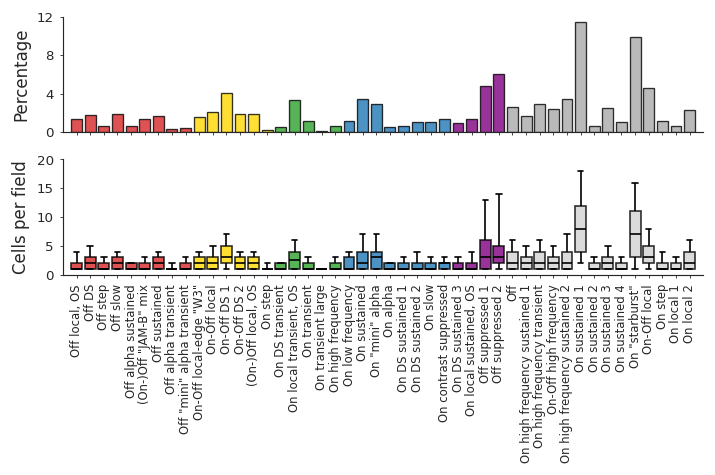

In [62]:
save = 0
fontsize_labels = 10


fig, ax = plt.subplot_mosaic("""
AAAA
BBBB
""",  figsize=(6,4))

###########################################
#####  Group distribution
###########################################
group_order = np.arange(1, len(group_ticks)+1)          
id_to_label = {gid: lab for gid, lab in zip(group_order, group_labels)}
percentages = (all_gcl_df['group_id'].value_counts(normalize=True).reindex(group_order, fill_value=0) * 100)
percent_data = pd.DataFrame({'group_id': group_order,'percentage': percentages.values})
bars = sns.barplot(data=percent_data, x='group_id', y='percentage', order=group_order, color='darkgray', edgecolor='k', alpha=0.8, ax=ax['A'])
ax['A'].set_xlabel('')
ax['A'].set_ylabel('Percentage',fontsize=fontsize_labels)
ax['A'].set_xlim(-1, group_order[-1])  
ax['A'].set_ylim(0,12)  
ax['A'].set_xticklabels([])
ax['A'].set_yticks([0, 4, 8, 12])
ax['A'].set_yticklabels(['0', '4', '8', '12'])
for i, bar in enumerate(bars.patches, start=1):
    if 1 <= i <= 9:
        bar.set_facecolor('tab:red')
    elif 10 <= i <= 15:
        bar.set_facecolor('gold')
    elif 16 <= i <= 20:
        bar.set_facecolor('tab:green')#
    elif 21 <= i <= 28:
        bar.set_facecolor('tab:blue')
    elif 29 <= i <= 32:
        bar.set_facecolor('purple')


###########################################
#####  cell count per field
###########################################
cells_per_type_per_field = (all_gcl_df.groupby(["experimenter", "date", "exp_num", "field", "group_id"]).size().reset_index(name="cell_count"))
stats_per_type = (cells_per_type_per_field.groupby("group_id")["cell_count"].agg(mean_cells="mean", std_cells="std").reset_index())

bars = sns.boxplot(
    data=cells_per_type_per_field,
    x="group_id",
    y="cell_count",
    whis=[10,90],          # whiskers at min and max
    showfliers=False,       # outliers suppressed (min/max already shown)
    color="lightgray",
    boxprops=dict(edgecolor="k",alpha=0.8),
    whiskerprops=dict(color="k"),
    capprops=dict(color="k"),
    medianprops=dict(color="k"),
    ax=ax['B'] 
)
ax['B'].set_xlabel('')
ax['B'].set_ylabel('Cells per field',fontsize=fontsize_labels)
positions = np.array(group_order) - 1
ax['B'].set_xticks(positions, gcl_group_names, rotation=90, fontsize=7)
ax['B'].set_xlim(-1, group_order[-1])
ax['B'].set_ylim(0,20)
ax['B'].set_yticks([0, 5, 10, 15, 20])
ax['B'].set_yticklabels(['0', '5', '10', '15', '20'])

for i, bar in enumerate(bars.patches, start=1):
    if 1 <= i <= 9:
        bar.set_facecolor('tab:red')
    elif 10 <= i <= 15:
        bar.set_facecolor('gold')
    elif 16 <= i <= 20:
        bar.set_facecolor('tab:green')
    elif 21 <= i <= 28:
        bar.set_facecolor('tab:blue')
    elif 29 <= i <= 32:
        bar.set_facecolor('purple')

fig.subplots_adjust(wspace=0.2, hspace=-0.1) 
sns.despine()
fig.tight_layout()

if save==1:
    figname = 'INSERT_FIGURE_NAME'
    fig.patch.set_facecolor('white')
    fig.savefig("YOUR_PATH/{}.png".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("YOUR_PATH/{}.svg".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)

--- 
## Plotting of functional responses and metrics

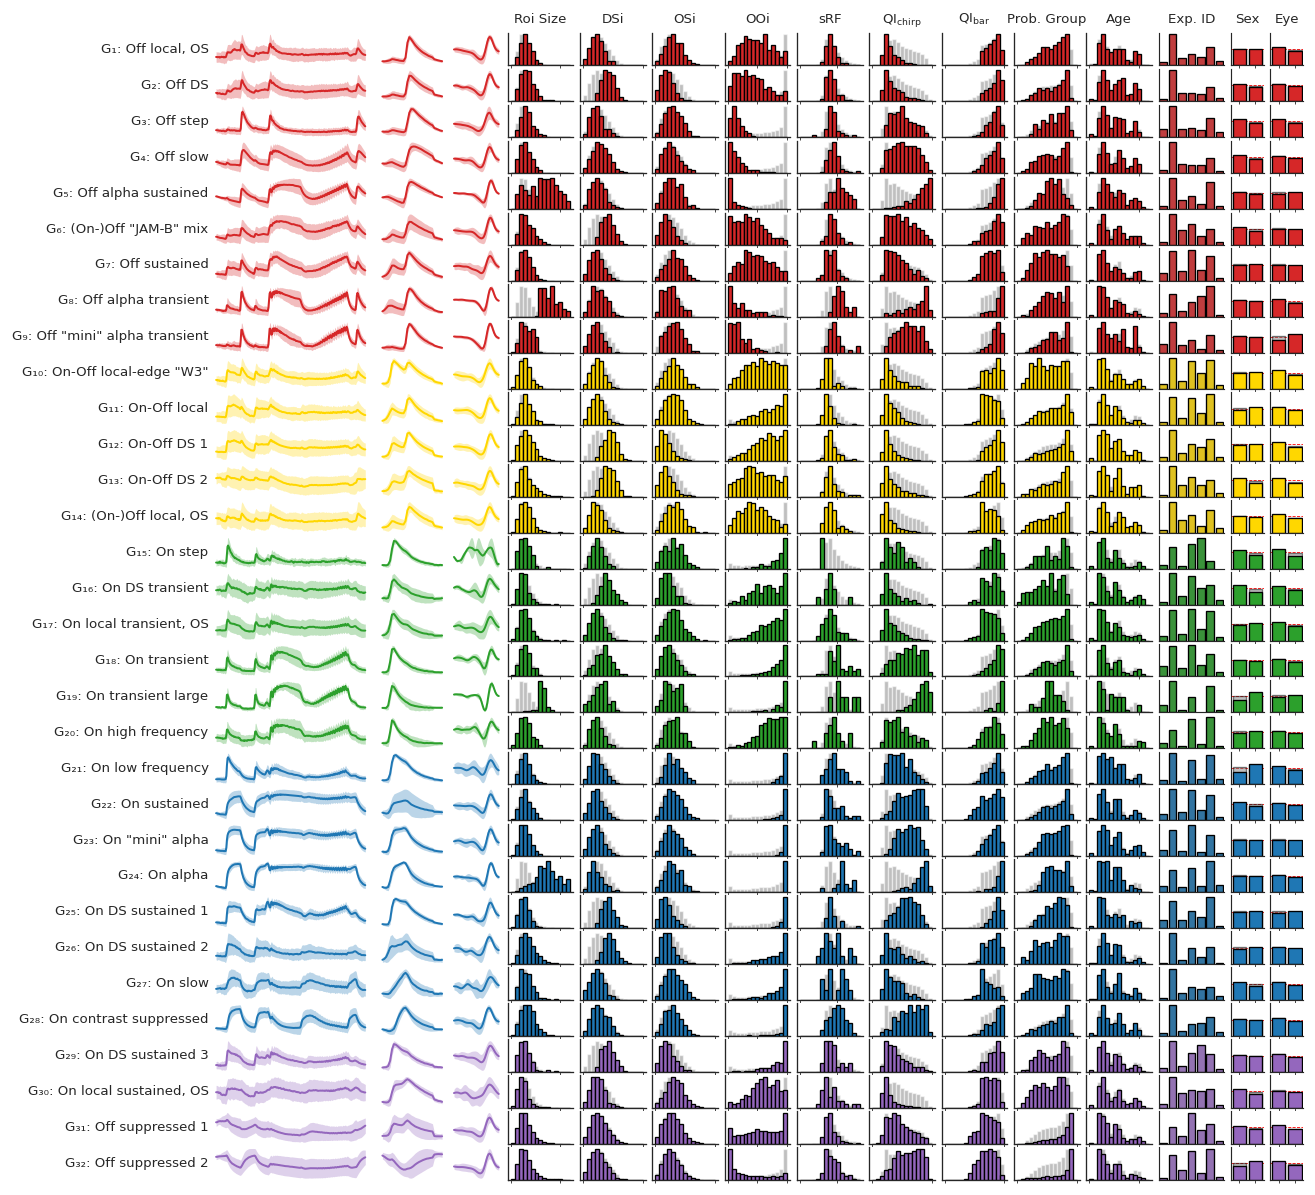

In [63]:
save = 0

n = 45
n_frames_chirp = chirp_data.shape[1]
n_frames_bar = bar_data_time.shape[1]
xlabel_fs = 8


fig,ax=plt.subplots(32,11+4,figsize=(11,10),gridspec_kw={'width_ratios': [2.5, 1., 0.75, 1., 1., 1., 1., 1., 1., 1., 1, 1, 1, 0.5, 0.5]})

for i in range(0,32):

    idx = np.where(all_gcl_df['group_id']==i+1)[0]

    # Chirp traces
    ax[i,0].plot(np.mean(chirp_data[idx],axis=0), color=colors[i])
    ax[i,0].fill_between(np.arange(0,n_frames_chirp,1),
                         np.mean(chirp_data[idx],axis=0) + np.std(chirp_data[idx],axis=0),
                         np.mean(chirp_data[idx],axis=0) - np.std(chirp_data[idx],axis=0),
                         alpha=0.3,
                         color=colors[i],
                         edgecolor="b",
                         linewidth=0.0)
    ax[i,0].axis('off')
    ax[i,0].text(0, 0.5, f'{group_labels[i]}: {gcl_group_names[i]}', transform=ax[i,0].transAxes, rotation=0, va='center', ha='right', fontsize=8)

    # MB traces
    ax[i,1].plot(np.roll(np.mean(bar_data_time[idx],axis=0),-5), color=colors[i])
    ax[i,1].fill_between(np.arange(0,n_frames_bar,1),
                         np.roll(np.mean(bar_data_time[idx],axis=0),-5) + np.roll(np.std(bar_data_time[idx],axis=0),-5),
                         np.roll(np.mean(bar_data_time[idx],axis=0),-5) - np.roll(np.std(bar_data_time[idx],axis=0),-5),
                         alpha=0.3,
                         color=colors[i],
                         edgecolor="b",
                         linewidth=0.0)
    ax[i,1].axis('off')


#### tRF
    filtered_trf_i = filtered_trf[filtered_trf['group_id'] == i + 1]['trf']
    if filtered_trf_i.empty:
        trf_array = np.zeros((0, 40))

    else:
        trf_array = np.stack(filtered_trf_i.values)

    ax[i,2].plot(np.mean(trf_array,axis=0), color=colors[i])
    ax[i,2].fill_between(np.arange(0,40,1),
                         np.mean(trf_array,axis=0) + np.std(trf_array,axis=0),
                         np.mean(trf_array,axis=0) - np.std(trf_array,axis=0),
                         alpha=0.3,
                         color=colors[i],
                         edgecolor="b",
                         linewidth=0.0)
    ax[i,2].axis('off')


#### roi size
    ax2 = ax[i,3].twinx()
    #background
    ax[i,3].hist(all_gcl_df['roi_size_um2'].values[:],
             range=[0,300],
             bins=15,
             color='gray',
             alpha=0.5,zorder=2)
    ax[0,3].set_title('Roi Size',fontsize=8)
    
    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['roi_size_um2'].values[:],
             range=[0,300],
             bins=15,
             edgecolor='k',
             color=colors[i],zorder=1,alpha=1)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,3].set_yticks([])
    ax2.set_yticks([])
    ax[i,3].get_yaxis().set_visible(False)


#### DSi
    ax2 = ax[i,4].twinx()
    # background
    ax[i,4].hist(all_gcl_df['bar_ds_index'].values[:],
             range=[0,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,4].set_title('DSi',fontsize=8)
    ax[i,4].set_xticklabels('')


    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['bar_ds_index'].values[:],
             range=[0,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('DSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,4].set_yticks([])
    ax2.set_yticks([])
    ax[i,4].get_yaxis().set_visible(False)

    
#### OSi
    ax2 = ax[i,5].twinx()
    # background
    ax[i,5].hist(all_gcl_df['bar_os_index'].values[:],
             range=[0,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,5].set_title('OSi',fontsize=8)
    ax[i,5].set_xticklabels('')
    

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['bar_os_index'].values[:],
             range=[0,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,5].set_yticks([])
    ax2.set_yticks([])
    ax[i,5].get_yaxis().set_visible(False)

    
#### OOI
    ax2 = ax[i,6].twinx()
    # background
    ax[i,6].hist(all_gcl_df['chirp_on_off_index'].values[:],
             range=[-1,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,6].set_title('OOi',fontsize=8)
    ax[i,6].set_xticklabels('')


    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['chirp_on_off_index'].values[:],
             range=[-1,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OOi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,6].set_yticks([])
    ax2.set_yticks([])
    ax[i,6].get_yaxis().set_visible(False)

#### spatial receptive field center diamener
    ax2 = ax[i,7].twinx()
    # background
    ax[i,7].hist(all_gcl_df['rf_cdia_um'].values[:],
             range=[0,400],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,7].set_title('sRF',fontsize=8)
    ax[i,7].set_xticklabels('')
    
    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['rf_cdia_um'].values[:],
             range=[0,400],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,7].set_yticks([])
    ax2.set_yticks([])
    ax[i,7].get_yaxis().set_visible(False)

    
#### Response Quality Chirp
    ax2 = ax[i,8].twinx()
    # background
    ax[i,8].hist(all_gcl_df['chirp_qidx'].values[:],
             range=[0,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,8].set_title('$QI_{chirp}$',fontsize=8)
    ax[i,8].set_xticklabels('')
    
    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['chirp_qidx'].values[:],
             range=[0,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,8].set_yticks([])
    ax2.set_yticks([])
    ax[i,8].get_yaxis().set_visible(False)

#### Response Quality Moving Bar
    ax2 = ax[i,9].twinx()
    # background
    ax[i,9].hist(all_gcl_df['bar_qidx'].values[:],
             range=[0,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,9].set_title('$QI_{bar}$',fontsize=8)
    ax[i,9].set_xticklabels('')
    
    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['bar_qidx'].values[:],
             range=[0,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,9].set_yticks([])
    ax2.set_yticks([])
    ax[i,9].get_yaxis().set_visible(False)


#### Confidence Score
    ax2 = ax[i,10].twinx()
    # background
    ax[i,10].hist(all_gcl_df['prob_group'].values[:],
             range=[0,1],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,10].set_title('Prob. Group',fontsize=8)
    ax[i,10].set_xticklabels('')
    
    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['prob_group'].values[:],
             range=[0,1],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('OSi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,10].set_yticks([])
    ax2.set_yticks([])
    ax[i,10].get_yaxis().set_visible(False)


#### age in weeks
    ax2 = ax[i,11].twinx()
    # background
    ax[i,11].hist(all_gcl_df['age_weeks'].values[:],
             range=[0,30],
             bins=15,
             color='gray',
             alpha=0.5)
    ax[0,11].set_title('Age',fontsize=8)
    ax[i,11].set_xticklabels('')

    ax2.hist(all_gcl_df[all_gcl_df['group_id'] == i+1]['age_weeks'].values[:],
             range=[0,30],
             bins=15,
             edgecolor='k',
             color=colors[i])
    #ax2.set_title('RTi',fontsize=8)
    ax2.set_xticklabels('')
    ax2.get_yaxis().set_visible(False)
    ax[i,11].set_yticks([])
    ax2.set_yticks([])
    ax[i,11].get_yaxis().set_visible(False)
    
    
##### experimenter distribution
    all_gcl_df['experimenter_id'] = all_gcl_df['experimenter_id'].astype('int').astype('string')
    subset = all_gcl_df[all_gcl_df['group_id'] == i+1]
    experimenter_order = list(range(1, 8))
    sns.countplot(x='experimenter_id', data=subset, color=colors[i], edgecolor='black', order=experimenter_order, ax=ax[i,12])
    ax[i,12].set_xticklabels('')
    ax[0,12].set_title('Exp. ID',fontsize=8)
    ax[i,12].get_yaxis().set_visible(False)
    ax[i,12].get_xaxis().set_visible(False)
    ax[i,12].set_yticks([])
    ax[i,12].set_xticks([])


    # --- SEX ---
    labels_sex = ['male', 'female']
    x = np.array([0, 1])           # bar centers at 0 and 1
    width = 0.8
    
    sex_all = all_gcl_df['animgender'].astype(str).str.lower()
    perc_all = (sex_all[sex_all.isin(labels_sex)]
                .value_counts(normalize=True)
                .reindex(labels_sex).fillna(0.0).mul(100))
    
    sex_type = all_gcl_df.loc[all_gcl_df['group_id'] == i+1, 'animgender'].astype(str).str.lower()
    perc_type = (sex_type[sex_type.isin(labels_sex)]
                 .value_counts(normalize=True)
                 .reindex(labels_sex).fillna(0.0).mul(100))
    
    ax[i,13].bar(x, perc_all.values, width=width, color=['gray','gray'], edgecolor='k', alpha=0.5, zorder=1)
    ax[i,13].bar(x, perc_type.values, width=width, color=[colors[i], colors[i]], edgecolor='k', zorder=2)
    ax[i,13].set_xlim(-0.5, 1.5)
    ax[i,13].set_ylim(0, 100)
    ax[i,13].tick_params(labelbottom=False, left=False)
    ax[i,13].yaxis.set_visible(False)
    if i == 0:
        ax[0,13].set_title('Sex', fontsize=8)
    ax[i,13].axhline(50, color='r', ls='--', lw=0.5, zorder=0)
    
    # --- EYE ---
    labels_eye = ['left', 'right']
    x = np.array([0, 1])           # same positions for eye
    width = 0.8
    
    eye_all = all_gcl_df['eye'].astype(str).str.lower()
    perc_all = (eye_all[eye_all.isin(labels_eye)]
                .value_counts(normalize=True)
                .reindex(labels_eye).fillna(0.0).mul(100))
    
    eye_type = all_gcl_df.loc[all_gcl_df['group_id'] == i+1, 'eye'].astype(str).str.lower()
    perc_type = (eye_type[eye_type.isin(labels_eye)]
                 .value_counts(normalize=True)
                 .reindex(labels_eye).fillna(0.0).mul(100))
    
    ax[i,14].bar(x, perc_all.values, width=width, color=['gray','gray'], edgecolor='k', alpha=0.5, zorder=1)
    ax[i,14].bar(x, perc_type.values, width=width, color=[colors[i], colors[i]], edgecolor='k', zorder=2)
    ax[i,14].set_xlim(-0.5, 1.5)
    ax[i,14].set_ylim(0, 100)
    ax[i,14].tick_params(labelbottom=False, left=False)
    ax[i,14].yaxis.set_visible(False)
    if i == 0:
        ax[0,14].set_title('Eye', fontsize=8)
    ax[i,14].axhline(50, color='r', ls='--', lw=0.5, zorder=0)

sns.despine()
fig.tight_layout()
fig.subplots_adjust(wspace=0.1, hspace=0.1)

if save==1:
    figname = 'INSERT_FIGURE_NAME'
    fig.patch.set_facecolor('white')
    fig.savefig("YOUR_PATH/{}.png".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)
    fig.savefig("YOUR_PATH/{}.svg".format(figname), dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor(), transparent=False)